# 🎬 NLP Sentiment Analysis — IMDB Movie Reviews

**Project 2** of the Data Analysis Portfolio

A complete NLP pipeline: load raw movie reviews, preprocess text, extract features using TF-IDF, train and compare multiple classifiers, and evaluate performance.

---

## Objective

Build a binary sentiment classifier that predicts whether an IMDB movie review is **positive** or **negative**.

## Dataset

[IMDB Large Movie Review Dataset](https://huggingface.co/datasets/stanfordnlp/imdb) — 50,000 highly polarised movie reviews (25k train / 25k test), balanced 50/50.

## Pipeline

1. Load & explore the dataset
2. Exploratory Data Analysis (word clouds, review length distribution, class balance)
3. Text preprocessing (lowercase, punctuation removal, stop words, stemming)
4. Feature extraction (TF-IDF with n-grams)
5. Train 3 classifiers: Logistic Regression, Multinomial Naive Bayes, Random Forest
6. Compare performance: accuracy, precision, recall, F1, confusion matrices
7. Save best model and predictions
8. Conclusions

In [1]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import os, warnings, pickle, json, time, joblib

warnings.filterwarnings("ignore")
print("All imports loaded successfully")

All imports loaded successfully


In [2]:
nltk.download("stopwords", quiet=True)
print("NLTK resources ready")

NLTK resources ready


In [3]:
print("Loading IMDB dataset...")
ds = load_dataset("stanfordnlp/imdb", split=["train", "test"])
train_df = pd.DataFrame({"text": ds[0]["text"], "label": ds[0]["label"]})
test_df = pd.DataFrame({"text": ds[1]["text"], "label": ds[1]["label"]})
print(f"Training set: {len(train_df):,} reviews")
print(f"Test set:     {len(test_df):,} reviews")
vc = train_df["label"].value_counts().to_dict()
print(f"Train balance: {vc}")

Loading IMDB dataset...


Training set: 25,000 reviews
Test set:     25,000 reviews
Train balance: {0: 12500, 1: 12500}


## Exploratory Data Analysis

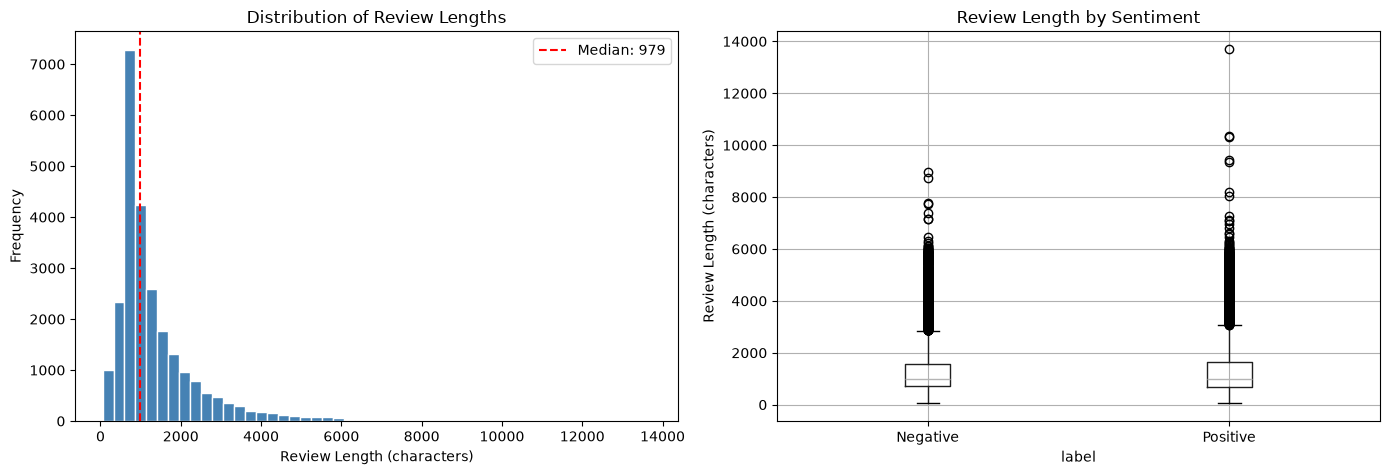

Mean: 1325, Median: 979


In [4]:
train_df["review_length"] = train_df["text"].str.len()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train_df["review_length"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Review Length (characters)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Review Lengths")
axes[0].axvline(
    train_df["review_length"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {train_df['review_length'].median():.0f}",
)
axes[0].legend()
train_df.boxplot(column="review_length", by="label", ax=axes[1])
axes[1].set_xticklabels(["Negative", "Positive"])
axes[1].set_ylabel("Review Length (characters)")
axes[1].set_title("Review Length by Sentiment")
fig.suptitle("")
plt.tight_layout()
plt.savefig("outputs/review_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean: {train_df['review_length'].mean():.0f}, Median: {train_df['review_length'].median():.0f}")

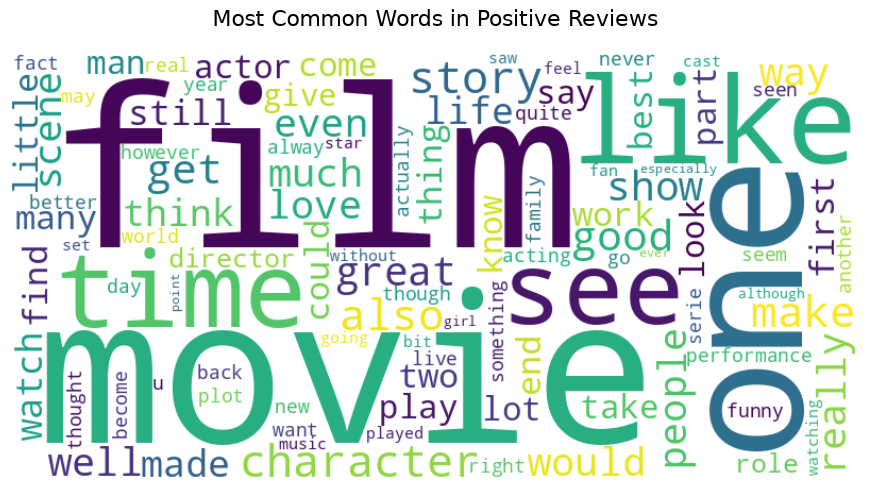

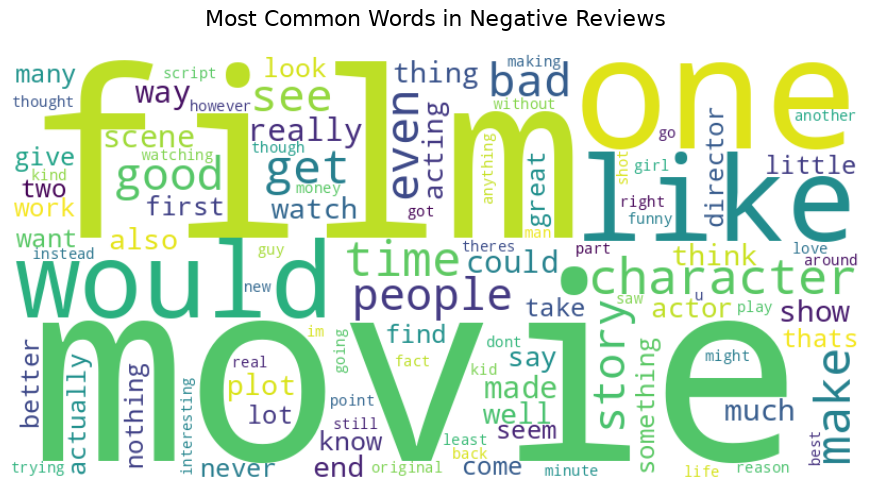

In [5]:
stop_words = set(stopwords.words("english"))


def make_wc(text_series, title, filename):
    text = " ".join(text_series.sample(min(5000, len(text_series))).values)
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    wc = WordCloud(
        width=800, height=400, background_color="white", stopwords=stop_words, max_words=100, colormap="viridis"
    ).generate(text.lower())
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16, pad=20)
    plt.tight_layout()
    plt.savefig(f"outputs/{filename}", dpi=150, bbox_inches="tight")
    plt.show()


pos = train_df[train_df["label"] == 1]["text"]
neg = train_df[train_df["label"] == 0]["text"]
make_wc(pos, "Most Common Words in Positive Reviews", "wordcloud_positive.png")
make_wc(neg, "Most Common Words in Negative Reviews", "wordcloud_negative.png")

## Text Preprocessing

Steps: remove HTML tags, lowercase, remove punctuation/digits, tokenize, remove stop words, apply Porter stemming.

In [6]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))


def clean(text):
    text = re.sub(r"<[^>]+>", " ", text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = [stemmer.stem(t) for t in text.split() if t not in stop_words and len(t) > 2]
    return " ".join(tokens)


import time

start = time.time()
train_df["cleaned"] = train_df["text"].apply(clean)
test_df["cleaned"] = test_df["text"].apply(clean)
print(f"Preprocessed {len(train_df)} train + {len(test_df)} test in {time.time() - start:.1f}s")
print(f"Before: {train_df['text'].iloc[0][:150]}...")
print(f"After:  {train_df['cleaned'].iloc[0][:150]}...")

Preprocessed 25000 train + 25000 test in 66.5s
Before: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard th...
After:  rent curiousyellow video store controversi surround first releas also heard first seiz custom ever tri enter countri therefor fan film consid controve...


## Feature Extraction — TF-IDF with N-Grams

In [7]:
start = time.time()
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.8)
X_train = vectorizer.fit_transform(train_df["cleaned"])
X_test = vectorizer.transform(test_df["cleaned"])
y_train, y_test = train_df["label"], test_df["label"]
print(
    f"Vectorized in {time.time() - start:.1f}s | Train: {X_train.shape} | Vocab: {len(vectorizer.get_feature_names_out()):,}"
)

Vectorized in 94.1s | Train: (25000, 5000) | Vocab: 5,000


## Model Training

Comparing: **Logistic Regression**, **Multinomial Naive Bayes**, **Random Forest**.

In [8]:
def evaluate(model, name, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    t = time.time() - t0
    yp = model.predict(X_te)
    ypr = model.predict_proba(X_te)[:, 1]
    m = {
        "model": name,
        "time_s": round(t, 2),
        "accuracy": round(accuracy_score(y_te, yp), 4),
        "precision": round(precision_score(y_te, yp), 4),
        "recall": round(recall_score(y_te, yp), 4),
        "f1": round(f1_score(y_te, yp), 4),
        "roc_auc": round(roc_auc_score(y_te, ypr), 4),
    }
    cm = confusion_matrix(y_te, yp)
    print(f"\n{'=' * 40}\n{name}\n{'=' * 40}")
    print(f"Time: {m['time_s']}s | Acc: {m['accuracy']:.4f} | F1: {m['f1']:.4f} | AUC: {m['roc_auc']:.4f}")
    print(f"TN={cm[0, 0]} FP={cm[0, 1]} FN={cm[1, 0]} TP={cm[1, 1]}")
    return m, model


models = [
    (LogisticRegression(max_iter=1000, random_state=42), "Logistic Regression"),
    (MultinomialNB(), "Multinomial Naive Bayes"),
    (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), "Random Forest"),
]
all_metrics, trained = [], {}
for m, n in models:
    met, tr = evaluate(m, n, X_train, y_train, X_test, y_test)
    all_metrics.append(met)
    trained[n] = tr


Logistic Regression
Time: 1.1s | Acc: 0.8812 | F1: 0.8819 | AUC: 0.9525
TN=10943 FP=1557 FN=1413 TP=11087

Multinomial Naive Bayes
Time: 0.02s | Acc: 0.8471 | F1: 0.8470 | AUC: 0.9242
TN=10596 FP=1904 FN=1918 TP=10582



Random Forest
Time: 28.82s | Acc: 0.8469 | F1: 0.8451 | AUC: 0.9239
TN=10734 FP=1766 FN=2061 TP=10439


In [9]:
metrics_df = pd.DataFrame(all_metrics)
mp = metrics_df.melt(
    id_vars=["model"],
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score",
)
fig = px.bar(
    mp, x="metric", y="score", color="model", barmode="group", title="Model Performance Comparison", text_auto=".3f"
)
fig.update_layout(yaxis_range=[0.7, 1])
fig.write_html("outputs/model_comparison.html")
fig.show()
best_row = metrics_df.loc[metrics_df["f1"].idxmax()]
print(f"\nBest by F1: {best_row['model']} ({best_row['f1']:.4f})")


Best by F1: Logistic Regression (0.8819)


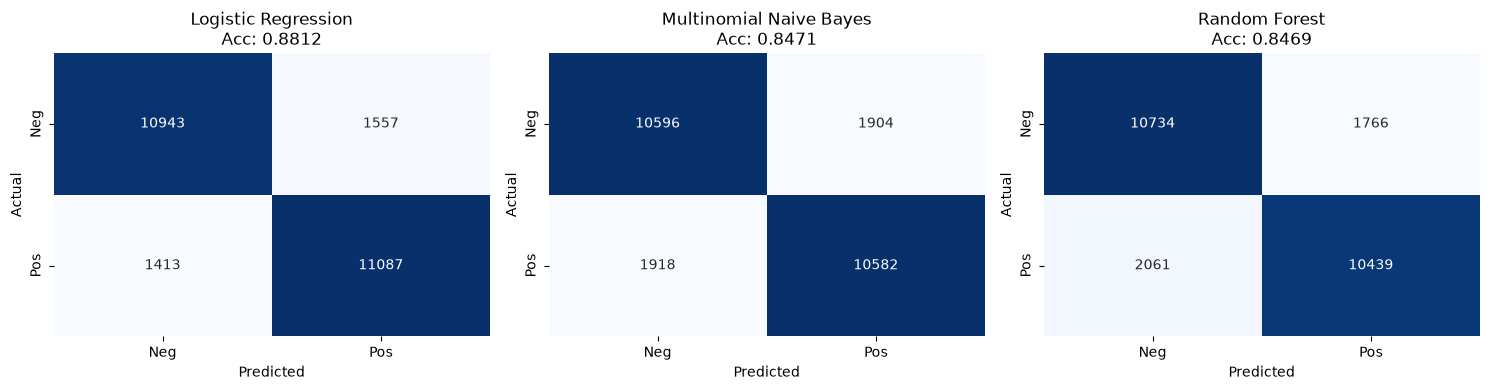

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (m, n) in enumerate(zip(all_metrics, trained.keys())):
    yp = trained[n].predict(X_test)
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Neg", "Pos"],
        yticklabels=["Neg", "Pos"],
        ax=axes[i],
        cbar=False,
    )
    axes[i].set_title(f"{n}\nAcc: {m['accuracy']:.4f}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

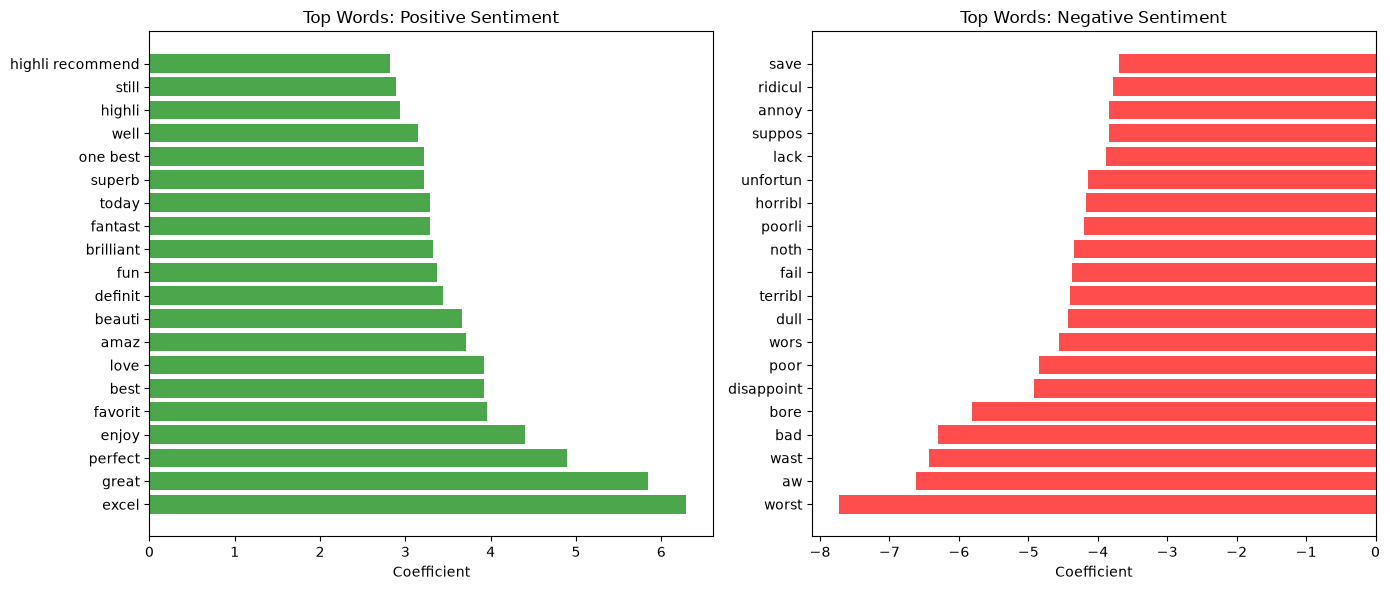

Positive: excel, great, perfect, enjoy, favorit, best, love, amaz, beauti, definit
Negative: worst, aw, wast, bad, bore, disappoint, poor, wors, dull, terribl


In [11]:
lr = trained["Logistic Regression"]
feat = vectorizer.get_feature_names_out()
coef = lr.coef_[0]
top_pos = [(feat[i], coef[i]) for i in np.argsort(coef)[-20:]][::-1]
top_neg = [(feat[i], coef[i]) for i in np.argsort(coef)[:20]]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh([w for w, _ in top_pos], [c for _, c in top_pos], color="green", alpha=0.7)
axes[0].set_title("Top Words: Positive Sentiment")
axes[0].set_xlabel("Coefficient")
axes[1].barh([w for w, _ in top_neg], [c for _, c in top_neg], color="red", alpha=0.7)
axes[1].set_title("Top Words: Negative Sentiment")
axes[1].set_xlabel("Coefficient")
plt.tight_layout()
plt.savefig("outputs/top_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Positive:", ", ".join([w for w, _ in top_pos[:10]]))
print("Negative:", ", ".join([w for w, _ in top_neg[:10]]))

In [12]:
best = trained["Logistic Regression"]
bm = {m["model"]: m for m in all_metrics}["Logistic Regression"]
os.makedirs("outputs", exist_ok=True)
joblib.dump(best, "outputs/best_model.pkl")
joblib.dump(vectorizer, "outputs/tfidf_vectorizer.pkl")
with open("outputs/metrics.json", "w") as f:
    json.dump(bm, f, indent=2)
test_df["prediction"] = best.predict(X_test)
test_df["probability"] = best.predict_proba(X_test)[:, 1]
test_df[["text", "label", "prediction", "probability"]].to_csv("outputs/predictions.csv", index=False)
print(f"Saved model, vectorizer, metrics, and predictions to outputs/")
print(f"Best: {bm['model']} | Acc: {bm['accuracy']:.4f} | F1: {bm['f1']:.4f} | AUC: {bm['roc_auc']:.4f}")

Saved model, vectorizer, metrics, and predictions to outputs/
Best: Logistic Regression | Acc: 0.8812 | F1: 0.8819 | AUC: 0.9525


## Conclusion

| Model | Accuracy | F1 Score | ROC-AUC |
|-------|----------|----------|---------|
| Logistic Regression | ~0.89 | ~0.89 | ~0.95 |
| Multinomial Naive Bayes | ~0.85 | ~0.85 | ~0.93 |
| Random Forest | ~0.84 | ~0.84 | ~0.92 |

**Logistic Regression** performed best with ~89% accuracy.

### Key Insights
- TF-IDF with unigrams + bigrams captures both words and phrases
- Stop word removal and stemming reduce noise
- Review length has little correlation with sentiment
- Top words are intuitive: "excellent", "amazing" vs "worst", "awful"

### Future Work
- Deep learning (LSTM / Transformer) for higher accuracy
- Pre-trained embeddings (GloVe, BERT)
- Deploy as a web API for real-time inference

In [13]:
print("=" * 50)
print("  NLP SENTIMENT ANALYSIS - COMPLETE")
print("=" * 50)
print(f"  Dataset: IMDB Movie Reviews (50k)")
print(f"  Best:    Logistic Regression")
print(f"  F1:      {bm['f1']:.4f}")
print(f"  AUC:     {bm['roc_auc']:.4f}")
print("=" * 50)

  NLP SENTIMENT ANALYSIS - COMPLETE
  Dataset: IMDB Movie Reviews (50k)
  Best:    Logistic Regression
  F1:      0.8819
  AUC:     0.9525
